**FACE RECOGNITION**

In [ ]:
!pip install cmake
!pip install dlib
!pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566162 sha256=e128ae80aacfc5aef5f5ae9918c3f0c1b03698f45401ced78770afba15503a82
  Stored in directory: /root/.cache/pip/wheels/7a/eb/cf/e9eced74122b679557f597bb7c8e4c739cfcac526db1fd523d
Successfully built face-recognition-models


In [ ]:
import cv2
import face_recognition

RuntimeError: Error while calling cudaGetDevice(&the_device_id) in file /root/.cache/uv/sdists-v4/pypi/dlib/19.24.2/X70kICKD8QKgWka2YcgDL/dlib-19.24.2.tar.gz/dlib/cuda/gpu_data.cpp:204. code: 35, reason: CUDA driver version is insufficient for CUDA runtime version

In [ ]:
modi_img=cv2.imread('/content/modi.jpg')
modi_encodings=face_recognition.face_encodings(modi_img)[0]

In [ ]:
trump_img=cv2.imread('/content/trump.jpg')
trump_encodings=face_recognition.face_encodings(trump_img)[0]

In [ ]:
face_encodings=[modi_encodings,trump_encodings]
face_names=['Narendra Modi','Donald Trump']

In [ ]:
image=cv2.imread('/content/Modi-Trump.jpg')
face_locations=face_recognition.face_locations(image)
face_encodings=face_recognition.face_encodings(image,face_locations)

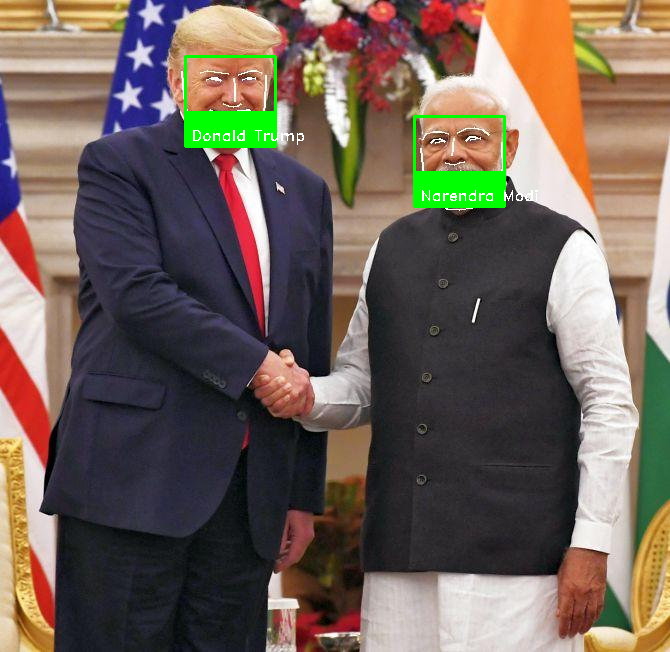

-1

In [ ]:
from google.colab.patches import cv2_imshow
import numpy as np

for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
  matches = face_recognition.compare_faces(face_encodings, face_encoding)
  name = 'Unknown'

  face_distances = face_recognition.face_distance(face_encodings, face_encoding)
  best_match_index = np.argmin(face_distances)
  if matches[best_match_index]:
    name = face_names[best_match_index]

  cv2.rectangle(image, (left, top), (right, bottom), (0, 255, 0), 2)

  cv2.rectangle(image, (left, bottom - 35), (right, bottom), (0, 255, 0), cv2.FILLED)
  font = cv2.FONT_HERSHEY_DUPLEX
  cv2.putText(image, name, (left + 6, bottom - 6), font, 0.5, (255, 255, 255), 1)

cv2_imshow(image)
cv2.waitKey(0)
